# Modelo basado en capas convolucionales para clasificación de dígitos

 Modelo preentrenado (formato .h5):

In [1]:
import requests

url = "https://huggingface.co/spaces/ayaanzaveri/mnist/resolve/main/mnist-model.h5"
r = requests.get(url)
with open("mnist_model.h5", "wb") as f:
    f.write(r.content)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


Usar el modelo descargado

In [2]:
from tensorflow.keras.models import load_model
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos de prueba
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Cargar el modelo preentrenado
model = load_model("mnist_model.h5")

# Carga el modelo con las metricas correctas

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

# Evaluar el modelo
loss, accuracy = model.evaluate(x_test, y_test)
print("Precisión en el conjunto de prueba:", accuracy)

313/313 [==============================] - 4s 6ms/step - loss: 0.0298 - accuracy: 0.9935
Precisión en el conjunto de prueba: 0.9934999942779541


In [ ]:
model.summary()

In [3]:
x_test.shape

(10000, 28, 28, 1)

Realizar una predicción

(-0.5, 27.5, 27.5, -0.5)

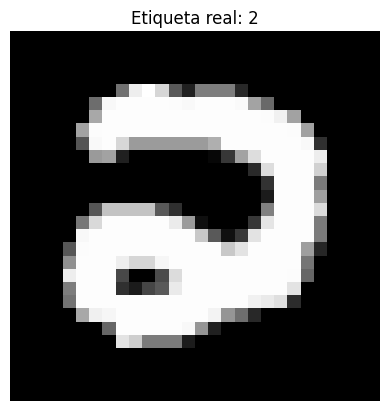

In [17]:
idx = 1352  # Cambia este índice para probar otras imágenes
img = x_test[idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Etiqueta real: {y_test[idx]}")
plt.axis('off')

In [18]:
prediction = model.predict(np.expand_dims(img, axis=0))
print(prediction)
print("Predicción del modelo:", np.argmax(prediction))

1/1 [==============================] - 0s 23ms/step
[[3.2106276e-10 1.5898419e-15 1.0000000e+00 2.0150598e-12 6.9157157e-14
  5.4933827e-12 2.2780284e-16 2.2018064e-11 5.5284327e-10 3.3262757e-14]]
Predicción del modelo: 2


In [16]:
prediction

array([[1.3113695e-12, 7.4177137e-17, 1.0000000e+00, 1.4618450e-12,
        1.3443227e-16, 7.5443177e-21, 1.0562105e-15, 3.3896736e-15,
        3.9369681e-15, 2.2210781e-15]], dtype=float32)

In [9]:
prediction.shape

(1, 10)

In [ ]:
# Imprimir la arquitectura del modelo
model.summary()

In [ ]:
# Visualizar los kernels de la primera capa convolucional
first_conv = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)][0]
kernels = first_conv.get_weights()[0]  # shape: (h, w, in_channels, num_filters)

print(f"Capa: {first_conv.name} | Forma de kernels: {kernels.shape}")

num_filters = kernels.shape[-1]
cols = 8
rows = (num_filters + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
axes = axes.flatten()

for i in range(num_filters):
    k = kernels[:, :, 0, i]
    k = (k - k.min()) / (k.max() - k.min() + 1e-8)
    axes[i].imshow(k, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'F{i}', fontsize=7)

for j in range(num_filters, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Kernels — {first_conv.name}', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Tamaño de los kernels de convolución
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(f"Capa: {layer.name}, Tamaño del kernel: {layer.kernel_size}")

# Ejemplo con imagen propia

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
img = cv2.imread('img_ej.jpg', cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [4]:
img_rgb.shape

(889, 667, 3)

(-0.5, 666.5, 888.5, -0.5)

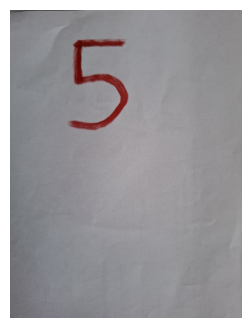

In [3]:
plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.axis('off')

(-0.5, 666.5, 888.5, -0.5)

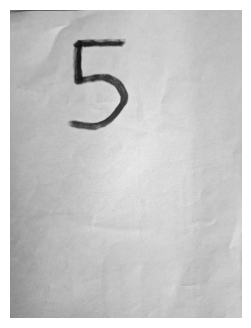

In [5]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(4, 4))
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

In [6]:
img_gray.shape

(889, 667)

(-0.5, 199.5, 299.5, -0.5)

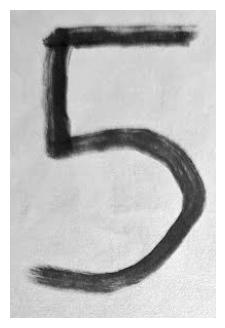

In [7]:
img_dig = img_gray[70:370, 150:350]

plt.figure(figsize=(4, 4))
plt.imshow(img_dig, cmap='gray')
plt.axis('off')

In [8]:
img_dig.shape

(300, 200)

(-0.5, 27.5, 27.5, -0.5)

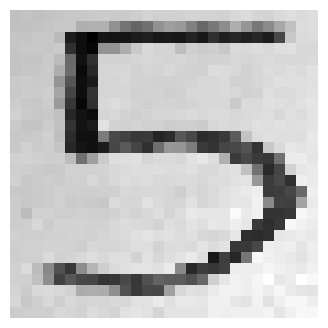

In [9]:
# Redimensionar la imagen a 28x28 píxeles
img_resized = cv2.resize(img_dig, (28, 28), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(4, 4))
plt.imshow(img_resized, cmap='gray')
plt.axis('off')

(-0.5, 27.5, 27.5, -0.5)

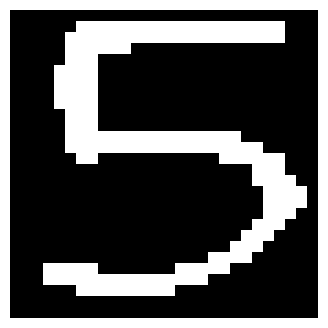

In [11]:
img_bin = np.where(img_resized > 128, 0, 255).astype('uint8')

plt.figure(figsize=(4, 4))
plt.imshow(img_bin, cmap='gray')
plt.axis('off')

In [12]:
img_bin.shape

(28, 28)

In [13]:
from tensorflow.keras.models import load_model

In [14]:
model = load_model("mnist_model.h5")
prediction = model.predict(np.expand_dims(img_bin, axis=0))

1/1 [==============================] - 2s 2s/step


In [15]:
prediction

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)

In [16]:
print("Predicción del modelo:", np.argmax(prediction))

Predicción del modelo: 5


## Ejercicio con imagen rotada

In [26]:
img_gray = cv2.imread('img_ej_rot.jpg', cv2.IMREAD_GRAYSCALE)

(-0.5, 269.5, 359.5, -0.5)

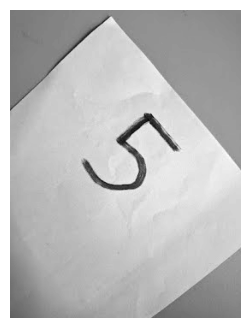

In [27]:
plt.figure(figsize=(4, 4))
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

In [28]:
img_gray.shape

(360, 270)

(-0.5, 129.5, 109.5, -0.5)

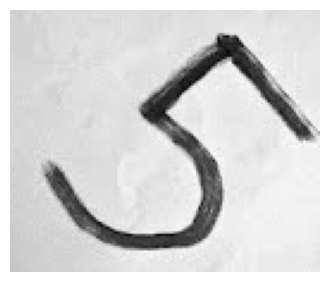

In [29]:
img_dig = img_gray[110:220, 70:200]
plt.figure(figsize=(4, 4))
plt.imshow(img_dig, cmap='gray')
plt.axis('off')

(-0.5, 129.5, 109.5, -0.5)

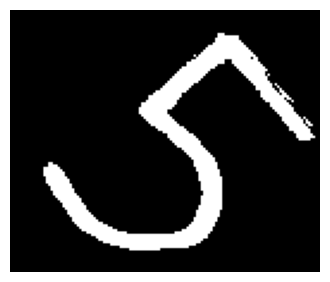

In [30]:
img_bin = np.where(img_dig > 128, 0, 255).astype('uint8')
plt.figure(figsize=(4, 4))
plt.imshow(img_bin, cmap='gray')
plt.axis('off')

(-0.5, 129.5, 109.5, -0.5)

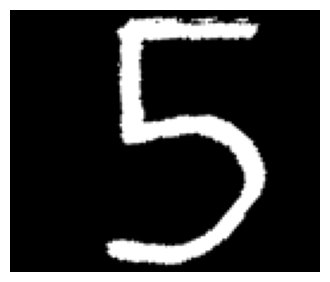

In [31]:
# Rotar la imagen alpha grados
alpha = 50 # Ángulo de rotación en grados
img_rot = cv2.warpAffine(img_bin, cv2.getRotationMatrix2D((img_bin.shape[1]//2, img_bin.shape[0]//2), alpha, 1), (img_bin.shape[1], img_bin.shape[0]))

plt.figure(figsize=(4, 4))
plt.imshow(img_rot, cmap='gray')
plt.axis('off')

In [34]:
img_rot.shape

(110, 130)

(-0.5, 27.5, 27.5, -0.5)

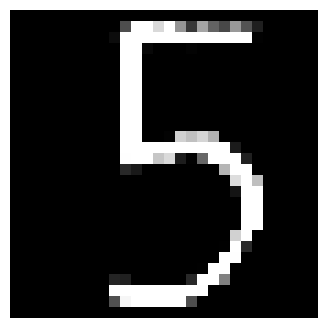

In [ ]:
img_rot = cv2.resize(img_rot, (28, 28), interpolation=cv2.INTER_CUBIC)
plt.figure(figsize=(4, 4))
plt.imshow(img_rot, cmap='gray')
plt.axis('off')

In [36]:
prediction = model.predict(np.expand_dims(img_rot, axis=0))

1/1 [==============================] - 0s 24ms/step


In [37]:
prediction

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)

In [38]:
print("Predicción del modelo:", np.argmax(prediction))

Predicción del modelo: 5
